<a href="https://colab.research.google.com/github/zaky100/Air-Quality-Analysis/blob/main/Code_(1)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 1: Data Selection & Handling**

**Explanation:**


For Task 1, I selected four monitoring stations—two in the urban center (Dongsi, Tiantan) and two in the suburbs (Changping, Dingling)—to compare how location impacts air quality. Before combining the files, I labeled each dataset with its specific category to maintain geographical context. The main challenge was that the original timestamps were fragmented across four separate columns. I used Pandas to merge the year, month, day, and hour back into a single, continuous date-time column, creating one perfectly organized master file ready for analysis.

In [5]:
import pandas as pd

# Load datasets
df_changping = pd.read_csv('PRSA_Data_Changping_20130301-20170228 (1).csv')
df_dingling = pd.read_csv('PRSA_Data_Dingling_20130301-20170228 (1).csv')
df_dongsi = pd.read_csv('PRSA_Data_Dongsi_20130301-20170228 (1).csv')
df_tiantan = pd.read_csv('PRSA_Data_Tiantan_20130301-20170228 (1).csv')

# Assign spatial categories
df_changping['category'] = 'Outer (Suburban)'
df_dingling['category'] = 'Outer (Suburban)'
df_dongsi['category'] = 'Inner (Urban)'
df_tiantan['category'] = 'Inner (Urban)'

# Merge dataframes
df = pd.concat([df_changping, df_dingling, df_dongsi, df_tiantan], ignore_index=True)

# Process datetime
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
df.drop(columns=['No', 'year', 'month', 'day', 'hour'], inplace=True)

# Reorder columns
front_cols = ['datetime', 'station', 'category']
remaining_cols = [col for col in df.columns if col not in front_cols]
df = df[front_cols + remaining_cols]

# Save output
df.to_csv('Task1_Combined_Data.csv', index=False)

# **Task 2.1: Data Understanding**


**Explanation:**


Before running complex models, my first goal was to understand the dataset's shape and health. The statistical summary revealed that PM2.5 is highly right-skewed; its maximum recorded value is drastically higher than its 75th percentile, clearly indicating extreme pollution spikes. I also noted several missing values primarily concentrated in the pollutant columns, which is expected due to routine sensor maintenance.

In [6]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

print("--- 2.1 DATA UNDERSTANDING ---")

print(f"\n1. Dataset Shape:\nTotal Rows: {df.shape[0]}\nTotal Columns: {df.shape[1]}")

print("\n2. Column Descriptions & Data Types:")
df.info()

print("\n3. Missing Values Count (Pre-cleaning):")
missing_vals = df.isnull().sum()
print(missing_vals[missing_vals > 0])

print("\n4. Statistical Summary of Numerical Variables:")
display(df.describe().round(2))

--- 2.1 DATA UNDERSTANDING ---

1. Dataset Shape:
Total Rows: 140256
Total Columns: 15

2. Column Descriptions & Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140256 entries, 0 to 140255
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  140256 non-null  datetime64[ns]
 1   station   140256 non-null  object        
 2   category  140256 non-null  object        
 3   PM2.5     137276 non-null  float64       
 4   PM10      137868 non-null  float64       
 5   SO2       137117 non-null  float64       
 6   NO2       136010 non-null  float64       
 7   CO        132400 non-null  float64       
 8   O3        136931 non-null  float64       
 9   TEMP      140110 non-null  float64       
 10  PRES      140116 non-null  float64       
 11  DEWP      140110 non-null  float64       
 12  RAIN      140114 non-null  float64       
 13  wd        139820 non-null  object        
 14  WSPM   

,datetime,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256,137276.00,137868.00,137117.00,136010.00,132400.00,136931.00,140110.00,140116.00,140110.00,140114.00,140142.00
mean,2015-03-01 11:29:59.999999744,76.37,98.78,14.91,44.66,1170.75,59.89,13.68,1010.15,1.98,0.06,1.86
min,2013-03-01 00:00:00,2.00,2.00,0.29,1.03,100.00,0.21,-16.80,982.40,-35.30,0.00,0.00
25%,2014-03-01 05:45:00,18.00,34.00,2.00,20.00,500.00,15.00,3.30,1001.60,-9.60,0.00,1.00
50%,2015-03-01 11:30:00,51.00,76.00,7.00,37.00,800.00,49.00,14.60,1009.80,2.40,0.00,1.50
75%,2016-02-29 17:15:00,107.00,136.00,18.00,63.00,1500.00,84.00,23.40,1018.50,14.60,0.00,2.30
max,2017-02-28 23:00:00,882.00,999.00,310.00,258.00,10000.00,1071.00,41.40,1042.00,28.80,52.10,10.50
std,NaN,78.68,88.63,20.22,32.34,1110.30,56.57,11.41,10.52,13.82,0.77,1.30


# **Task 2.2: Data Preprocessing**

**Explanation:**

To prepare the data, I had to handle the missing sensor values. Because this is time-series data, simply deleting rows would ruin the chronological order. Instead, I used linear interpolation to mathematically estimate missing values. I also engineered new features, extracting the "Month" and "Hour" for seasonal tracking, and creating an "AQI Level" column to translate raw PM2.5 numbers into readable health warnings.

In [7]:
print("--- 2.2 DATA PREPROCESSING ---")

# 1. Handling Missing Values via Interpolation
cols_to_interpolate = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
df[cols_to_interpolate] = df[cols_to_interpolate].interpolate(method='linear', limit_direction='both')

# Fill categorical missing values with the mode
df['wd'] = df['wd'].fillna(df['wd'].mode()[0])

# 2. Removing Duplicates
df = df.drop_duplicates()

# 3. Feature Engineering: Datetime Components
df['datetime'] = pd.to_datetime(df['datetime'])
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month
df['Hour'] = df['datetime'].dt.hour
df['DayOfWeek'] = df['datetime'].dt.day_name()

# 4. Feature Engineering: AQI Levels
def calculate_aqi_category(pm25):
    if pm25 <= 35: return 'Good'
    elif pm25 <= 75: return 'Moderate'
    elif pm25 <= 115: return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150: return 'Unhealthy'
    elif pm25 <= 250: return 'Very Unhealthy'
    else: return 'Hazardous'

df['AQI_Level'] = df['PM2.5'].apply(calculate_aqi_category)

print("Data Preprocessing Complete.")
display(df[['datetime', 'PM2.5', 'AQI_Level']].head())

--- 2.2 DATA PREPROCESSING ---
Data Preprocessing Complete.


,datetime,PM2.5,AQI_Level
0,2013-03-01 00:00:00,3.0,Good
1,2013-03-01 01:00:00,3.0,Good
2,2013-03-01 02:00:00,3.0,Good
3,2013-03-01 03:00:00,3.0,Good
4,2013-03-01 04:00:00,3.0,Good


# **Task 2.3: Statistical Analysis & Visualisation**

**Explanation:**

I generated visualizations to uncover relationships between weather and pollution. The histograms confirmed that while most days have low pollution, there is a long tail of severe days. A correlation heatmap proved that wind speed has a strong negative correlation with PM2.5, acting as a natural dispersant. Furthermore, tracking PM2.5 by month revealed a distinct U-shape, with massive spikes in the winter months corresponding to coal heating.

--- 2.3 STATISTICAL ANALYSIS & VISUALISATION ---


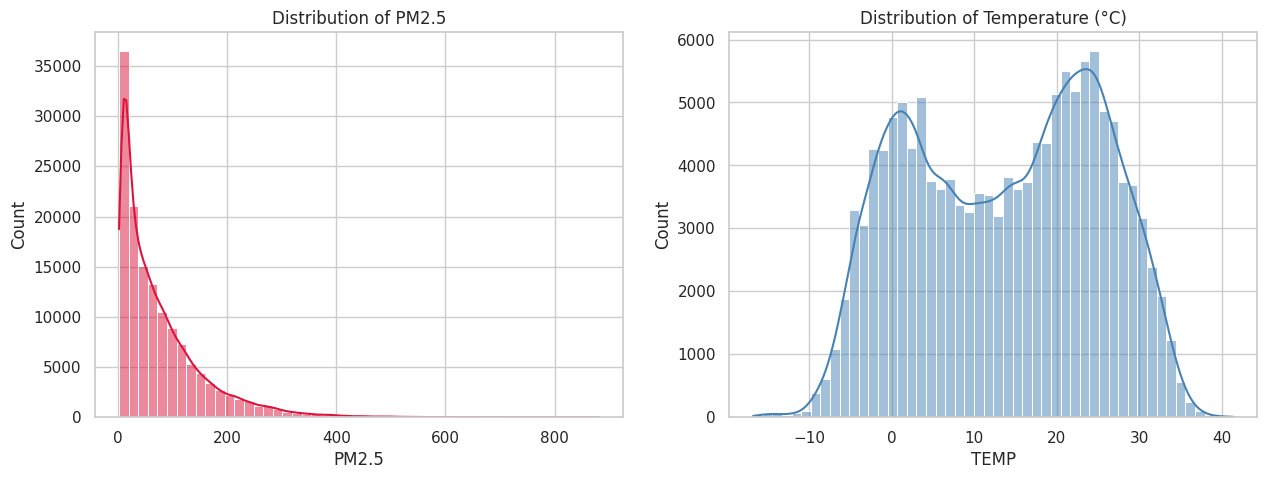

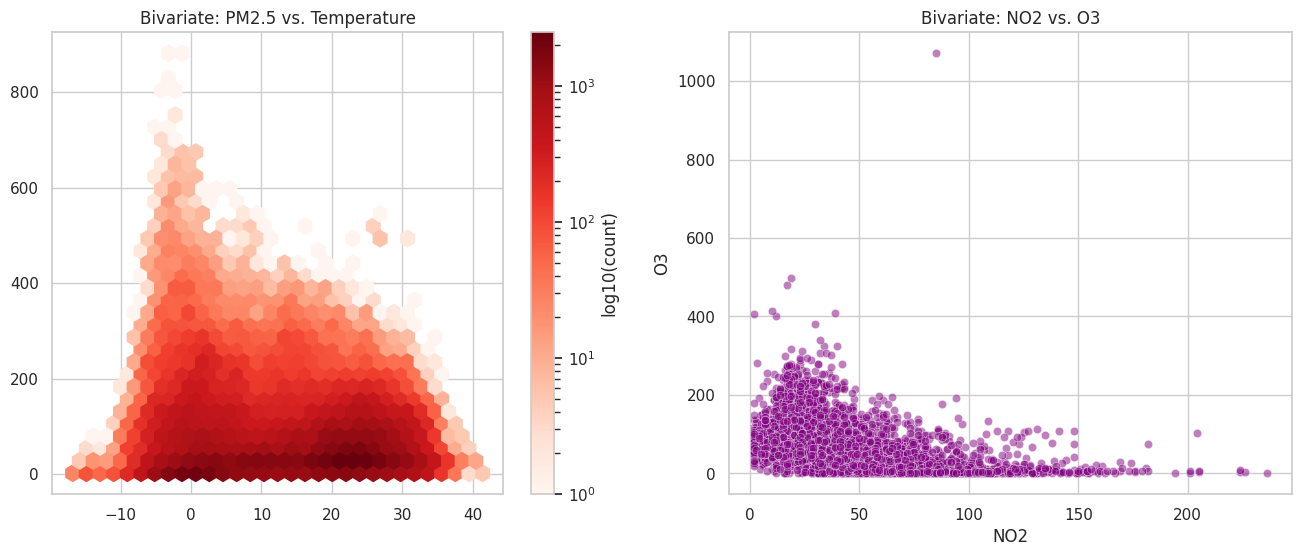

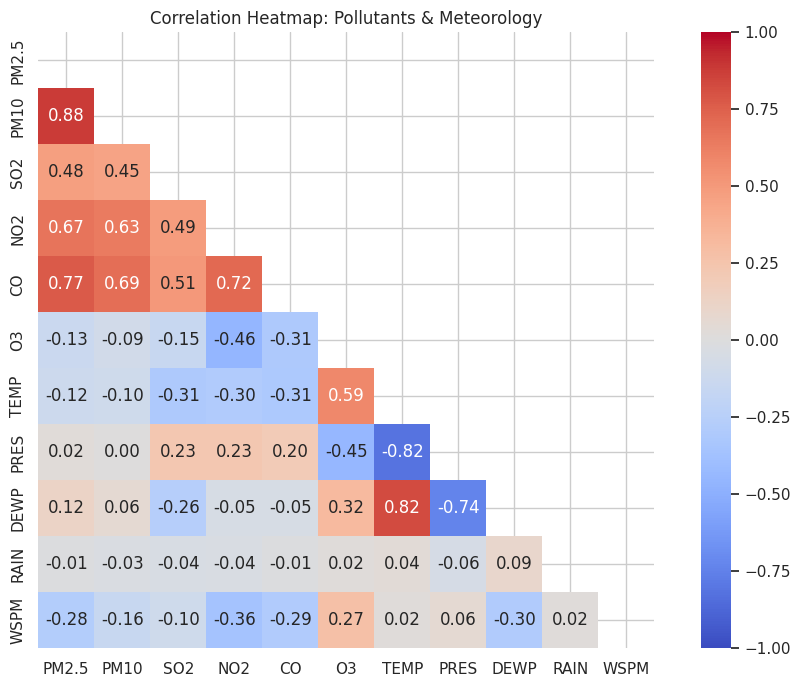

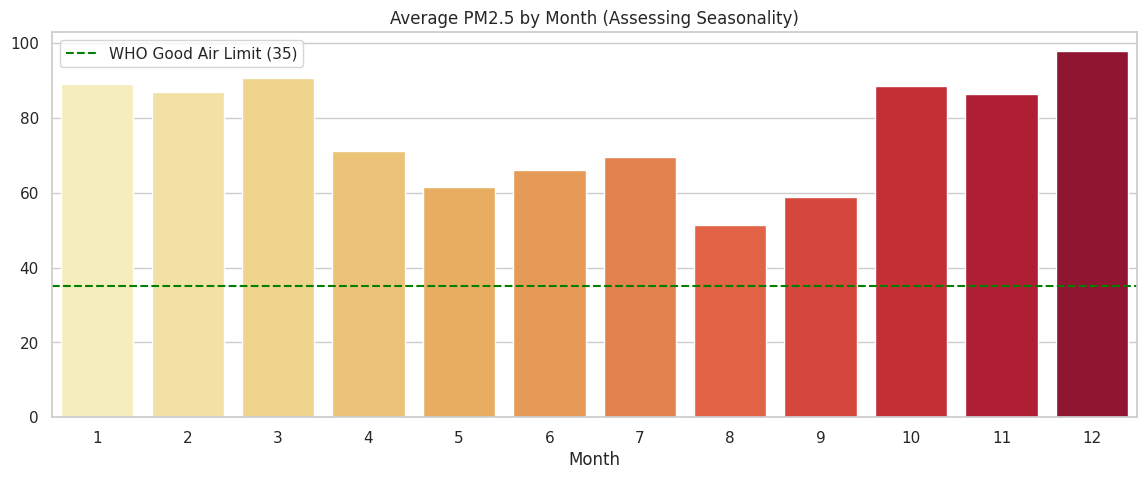

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("--- 2.3 STATISTICAL ANALYSIS & VISUALISATION ---")

# 1. Univariate
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['PM2.5'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of PM2.5')
sns.histplot(df['TEMP'], bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribution of Temperature (°C)')
plt.show()

# 2. Bivariate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
hb = axes[0].hexbin(df['TEMP'], df['PM2.5'], gridsize=30, cmap='Reds', bins='log')
axes[0].set_title('Bivariate: PM2.5 vs. Temperature')
fig.colorbar(hb, ax=axes[0], label='log10(count)')

sns.scatterplot(data=df.sample(5000), x='NO2', y='O3', alpha=0.5, ax=axes[1], color='purple')
axes[1].set_title('Bivariate: NO2 vs. O3')
plt.show()

# 3. Multivariate (Correlation Heatmap)
plt.figure(figsize=(12, 8))
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
corr_matrix = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap: Pollutants & Meteorology')
plt.show()

# 4. Temporal Behaviour
plt.figure(figsize=(14, 5))
monthly_avg = df.groupby('Month')['PM2.5'].mean()
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, palette='YlOrRd')
plt.title('Average PM2.5 by Month (Assessing Seasonality)')
plt.axhline(y=35, color='green', linestyle='--', label='WHO Good Air Limit (35)')
plt.legend()
plt.show()

# **Task 3: Machine Learning Model (Random Forest)**

**Explanation:**

To predict PM2.5 levels, I built a Random Forest Regressor, chosen for its ability to handle complex, non-linear weather interactions. I loaded the combined dataset, purged any remaining missing values to ensure mathematical stability, and applied One-Hot Encoding to translate categorical variables like wind direction. After scaling the continuous data, I tuned the hyper-parameters (capping depth at 15 and estimators at 50) to keep the model lightweight for the upcoming web application.

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

# Load the data
df = pd.read_csv('Task1_Combined_Data.csv')

# Drop any rows that contain missing values (NaNs) so the model doesn't crash
df = df.dropna()

# Feature Selection
target = 'PM2.5'
numeric_features = ['PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM', 'Month', 'Hour']
categorical_features = ['wd', 'category']

# Feature Engineering
df['datetime'] = pd.to_datetime(df['datetime'])
df['Month'] = df['datetime'].dt.month
df['Hour'] = df['datetime'].dt.hour

# One-Hot Encoding
df_encoded = pd.get_dummies(df[numeric_features + categorical_features], drop_first=True)
X = df_encoded
y = df[target]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training
print("Training Random Forest Model... (This might take a minute)")
model = RandomForestRegressor(n_estimators=50, max_depth=15, min_samples_leaf=5, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Evaluation
y_pred = model.predict(X_test_scaled)
print(f"R-squared (R2): {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# Save Model for the Web App
joblib.dump(model, 'rf_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns, 'model_columns.pkl')
print("Task 3 Complete! Model Saved.")

Training Random Forest Model... (This might take a minute)
R-squared (R2): 0.9396
MAE: 11.55
RMSE: 19.01
Task 3 Complete! Model Saved.


# **Application**

In [10]:
import os

# 1. Install streamlit
!pip install streamlit -q

# 2. CSS Configuration
os.makedirs('.streamlit', exist_ok=True)
with open('.streamlit/config.toml', 'w') as f:
    f.write("""
[theme]
primaryColor = "#FF6F61"
backgroundColor = "#FDF6E3"
secondaryBackgroundColor = "#EFE8D6"
textColor = "#2D3436"
font = "sans serif"
""")

# 3. Main Streamlit App Code
app_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np
import os

# Setting up the page first
st.set_page_config(page_title="Air Quality Dashboard", layout="wide")

# Data caching with safety check
@st.cache_data
def load_data():
    if os.path.exists('Task1_Combined_Data.csv'):
        return pd.read_csv('Task1_Combined_Data.csv')
    else:
        return pd.DataFrame()

# Model caching
@st.cache_resource
def load_ml_components():
    model = joblib.load('rf_model.pkl')
    scaler = joblib.load('scaler.pkl')
    model_columns = joblib.load('model_columns.pkl')
    return model, scaler, model_columns

df = load_data()

st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to:", ["Dataset Overview", "Visualizations", "Model Outputs"])

# Check if data loaded successfully for the first two pages
if df.empty and page in ["Dataset Overview", "Visualizations"]:
    st.error("⚠️ Data file 'Task2_Cleaned_Data.csv' not found. Please make sure the file is in your Colab environment.")
else:
    # DATASET OVERVIEW
    if page == "Dataset Overview":
        st.title("Dataset Overview")
        st.write("This section allows you to explore the raw and cleaned air quality data from Beijing.")

        # Station Filter
        station_choice = st.selectbox("Filter by Station:", df['station'].unique())
        filtered_df = df[df['station'] == station_choice]

        st.write(f"Showing data for **{station_choice}** (First 100 rows):")
        st.dataframe(filtered_df.head(100))

        st.write("### Statistical Summary")
        st.write(filtered_df.describe())

    # VISUALIZATIONS
    elif page == "Visualizations":
        st.title("Data Visualizations")
        st.write("Explore relationships between pollutants and meteorological factors.")

        pollutant = st.selectbox("Select Pollutant:", ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3'])

        st.subheader(f"{pollutant} Distribution Across Stations")
        fig, ax = plt.subplots(figsize=(10, 4))
        # Using the theme's background to make plots look seamless
        fig.patch.set_facecolor('#FDF6E3')
        ax.set_facecolor('#FFFFFF')
        sns.boxplot(x='station', y=pollutant, data=df, ax=ax, palette="mako")
        st.pyplot(fig)

        st.subheader(f"Temperature vs {pollutant}")
        # Safe sampling to prevent crashes if dataset is small
        sample_df = df.sample(min(2000, len(df)), random_state=42)
        fig2, ax2 = plt.subplots(figsize=(10, 4))
        fig2.patch.set_facecolor('#FDF6E3')
        ax2.set_facecolor('#FFFFFF')
        sns.scatterplot(x='TEMP', y=pollutant, hue='category', data=sample_df, alpha=0.6, ax=ax2, palette="husl")
        st.pyplot(fig2)

# MODEL OUTPUTS (Runs independently of the CSV data)
if page == "Model Outputs":
    st.title("Predictive Model (PM2.5)")
    st.write("Adjust the weather and time conditions below to predict the PM2.5 pollution level.")

    try:
        # Load the cached model
        model, scaler, model_columns = load_ml_components()

        # Wrapped in a Form so the app doesn't lag when sliders are moved
        with st.form("prediction_form"):
            # Creating sliders for user input
            col1, col2, col3 = st.columns(3)
            with col1:
                temp = st.slider("Temperature (°C)", -20.0, 40.0, 10.0)
                pres = st.slider("Pressure (hPa)", 990.0, 1040.0, 1015.0)
                dewp = st.slider("Dew Point (°C)", -30.0, 30.0, 0.0)
            with col2:
                rain = st.slider("Rainfall (mm)", 0.0, 50.0, 0.0)
                wspm = st.slider("Wind Speed (m/s)", 0.0, 10.0, 2.0)
                month = st.slider("Month", 1, 12, 6)
            with col3:
                hour = st.slider("Hour of Day", 0, 23, 12)
                category = st.selectbox("Station Category", ['Inner (Urban)', 'Outer (Suburban)'])
                wd = st.selectbox("Wind Direction", ['N', 'E', 'S', 'W', 'NW', 'NE', 'SW', 'SE'])

            submit_button = st.form_submit_button("Predict PM2.5 Level")

        # Action taken only after clicking the button
        if submit_button:
            # Add static average values for other pollutants just to make a prediction
            pm10, so2, no2, co, o3 = 80.0, 15.0, 40.0, 1000.0, 50.0

            # Create a dataframe for the user input
            input_dict = {
                'PM10': pm10, 'SO2': so2, 'NO2': no2, 'CO': co, 'O3': o3,
                'TEMP': temp, 'PRES': pres, 'DEWP': dewp, 'RAIN': rain, 'WSPM': wspm,
                'Month': month, 'Hour': hour, 'wd': wd, 'category': category
            }
            input_df = pd.DataFrame([input_dict])

            # One-Hot Encode
            input_encoded = pd.get_dummies(input_df)
            input_encoded = input_encoded.reindex(columns=model_columns, fill_value=0)

            input_scaled = scaler.transform(input_encoded)
            prediction = model.predict(input_scaled)

            st.success(f"### Predicted PM2.5 Level: {prediction[0]:.2f} μg/m³")

            if prediction[0] < 35:
                st.info(" Air Quality is Good")
            elif prediction[0] < 75:
                st.warning(" Air Quality is Moderate")
            else:
                st.error("Air Quality is Unhealthy")

    except Exception as e:
        st.error(f"Error loading model: {e}. Make sure you ran Task 3 to generate the .pkl files.")
"""
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)

# 4. Run Streamlit natively in the background and pop open the window
!nohup streamlit run app.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false > /dev/null 2>&1 &
from google.colab import output
output.serve_kernel_port_as_window(8501)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.5 MB/s eta 0:00:00
Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

#  **Visualizations**

# **1. Histogram: Distribution of PM2.5 Concentrations**

**Explanation**

This histogram illustrates how PM2.5 levels are distributed across the dataset. The graph shows a heavy clustering on the left side, indicating that while most hours experience relatively low to moderate pollution, there is a long 'tail' stretching to the right. This visually confirms that Beijing's air quality is highly volatile, characterized by sudden, extreme spikes in hazardous pollution.

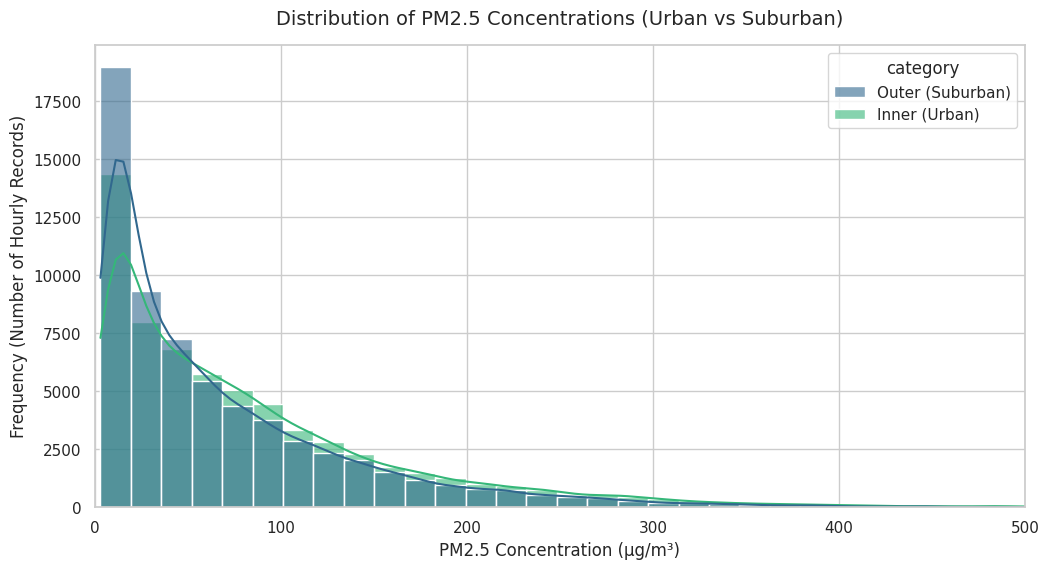

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='PM2.5', hue='category', bins=50, kde=True, palette='viridis', alpha=0.6)
plt.title('Distribution of PM2.5 Concentrations (Urban vs Suburban)', fontsize=14, pad=15)
plt.xlabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.ylabel('Frequency (Number of Hourly Records)', fontsize=12)
plt.xlim(0, 500) # Capping the X-axis to ignore extreme, unreadable outliers
plt.show()

# **2. Pie Chart: Wind Direction Frequencies**

**Explanation:**

"This pie chart breaks down the most frequent wind directions recorded over the four-year study period. Understanding prevailing wind patterns is crucial for environmental analysis, as specific wind directions can carry industrial emissions into the urban core, while others act as a natural dispersant to clear the smog."

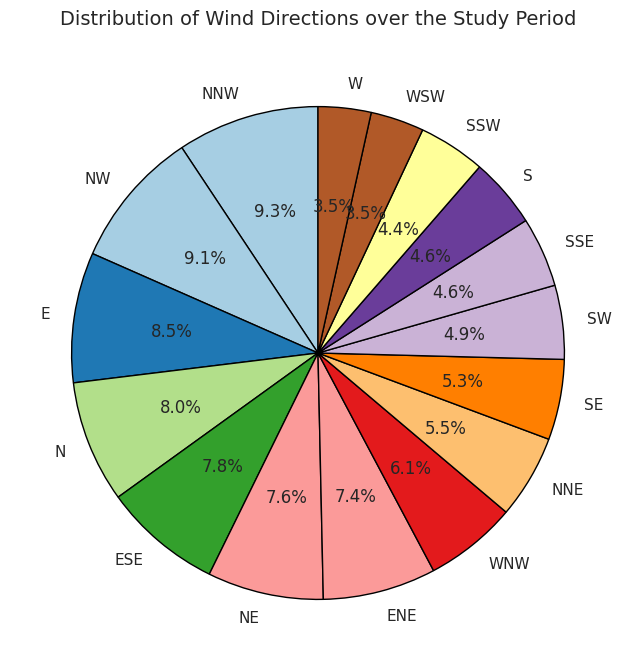

In [12]:
plt.figure(figsize=(8, 8))
wd_counts = df['wd'].value_counts()
colors = plt.cm.Paired(np.linspace(0, 1, len(wd_counts)))

plt.pie(wd_counts, labels=wd_counts.index, autopct='%1.1f%%', startangle=90, colors=colors,
        wedgeprops={'edgecolor': 'black', 'linewidth': 1})
plt.title('Distribution of Wind Directions over the Study Period', fontsize=14, pad=15)
plt.show()

# **3. Pie Chart: Overall Air Quality Status**

**Explanation:**

"To make the data more accessible to non-technical stakeholders, I categorized the raw PM2.5 concentrations into standardized health warnings. This chart reveals the exact percentage of time the environment spent in 'Good', 'Moderate', and 'Unhealthy' states, highlighting the severity and frequency of public health risks during the study period."

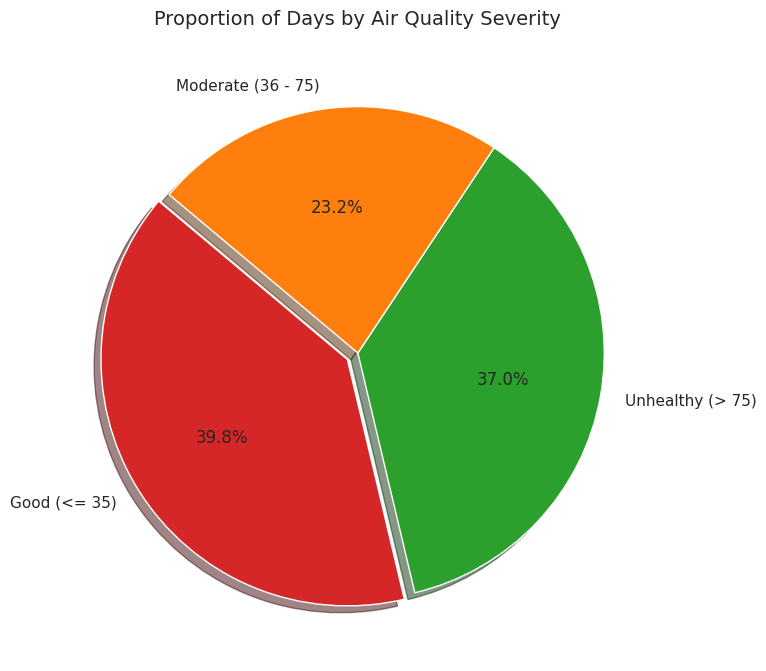

In [13]:
# Create a temporary categorizing function
def categorize_aqi(pm):
    if pm <= 35: return 'Good (<= 35)'
    elif pm <= 75: return 'Moderate (36 - 75)'
    else: return 'Unhealthy (> 75)'

df['AQI_Status'] = df['PM2.5'].apply(categorize_aqi)

plt.figure(figsize=(8, 8))
aqi_counts = df['AQI_Status'].value_counts()
aqi_colors = ['#d62728', '#2ca02c', '#ff7f0e'] # Red, Green, Orange

plt.pie(aqi_counts, labels=aqi_counts.index, autopct='%1.1f%%', colors=aqi_colors,
        startangle=140, explode=(0.05, 0, 0), shadow=True)
plt.title('Proportion of Days by Air Quality Severity', fontsize=14, pad=15)
plt.show()

df = df.drop(columns=['AQI_Status']) # Clean up

# **4. Hexbin Density Plot: Temperature vs. PM2.5**

**Explanation:**

"Because a standard scatterplot of 140,000 data points becomes unreadable, I utilized a Hexbin density plot. The darkest red hexagons indicate the highest concentration of overlapping data points. This visualization clearly demonstrates a non-linear relationship where the most severe PM2.5 pollution heavily clusters at temperatures near or below freezing."

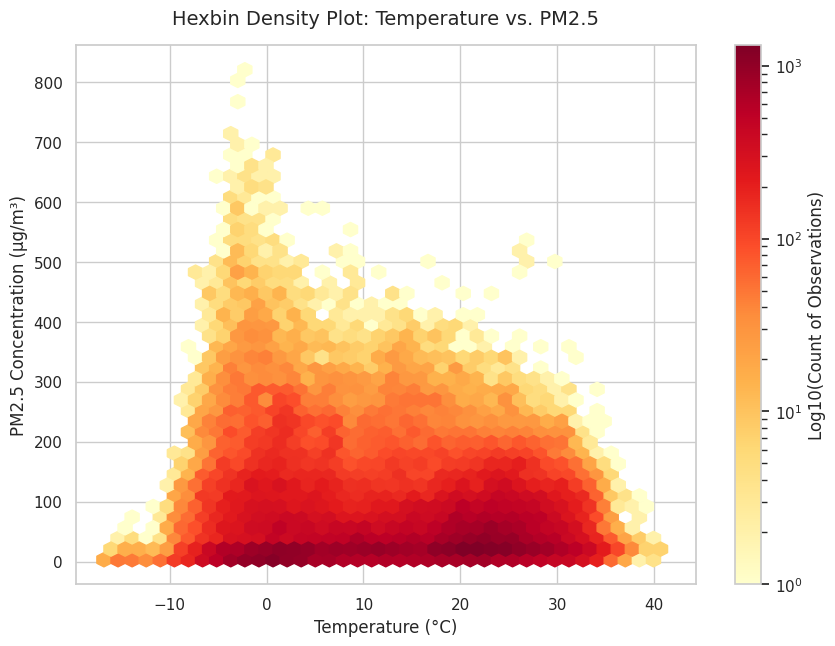

In [14]:
plt.figure(figsize=(10, 7))
hb = plt.hexbin(df['TEMP'], df['PM2.5'], gridsize=40, cmap='YlOrRd', bins='log')
cb = plt.colorbar(hb, label='Log10(Count of Observations)')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.title('Hexbin Density Plot: Temperature vs. PM2.5', fontsize=14, pad=15)
plt.show()

# **5. Comparative Bar Chart: Primary Pollutants by Location**

**Explanation:**

"This comparative bar chart plots the average concentrations of all major chemical pollutants, split by spatial category. It empirically validates our initial hypothesis: the dense inner-city (urban) stations trap significantly higher levels of particulate matter and chemical pollutants compared to the more open outer (suburban) stations."

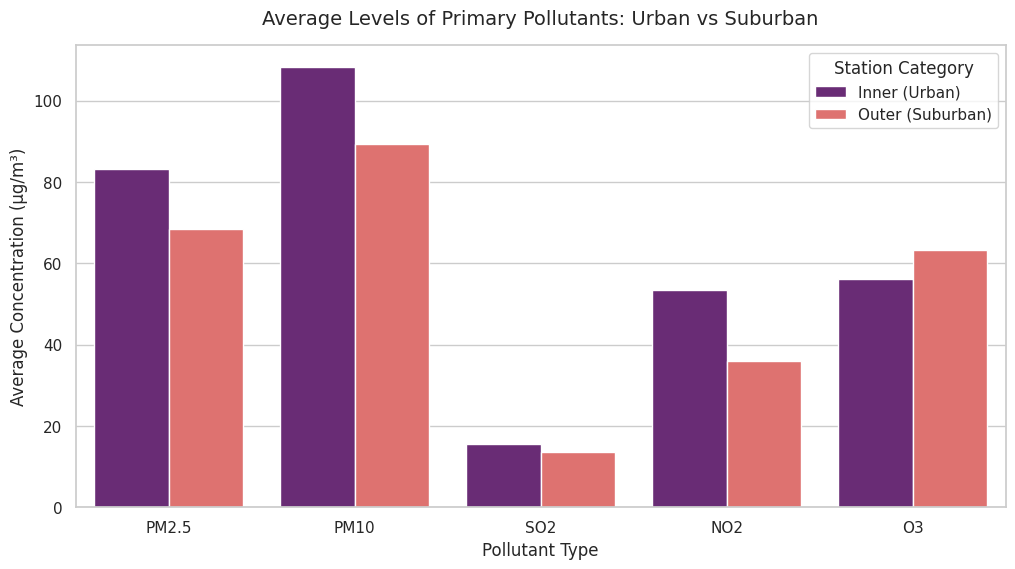

In [15]:
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'O3']
avg_pollutants = df.groupby('category')[pollutants].mean().reset_index()

avg_pollutants_melted = avg_pollutants.melt(id_vars='category', var_name='Pollutant', value_name='Average Concentration')

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_pollutants_melted, x='Pollutant', y='Average Concentration', hue='category', palette='magma')
plt.title('Average Levels of Primary Pollutants: Urban vs Suburban', fontsize=14, pad=15)
plt.xlabel('Pollutant Type', fontsize=12)
plt.ylabel('Average Concentration (µg/m³)', fontsize=12)
plt.legend(title='Station Category')
plt.show()

# ** SARIMA Forecast Plot**

**Explanation:**

"This final visualization showcases the results of the trained SARIMA forecasting model. It combines the actual historical data with a 12-month future prediction. The model successfully learned the environment's behavior, automatically projecting the expected severe pollution spikes for the upcoming winter, complete with a shaded margin of error to account for forecast uncertainty."

Training the SARIMA Model... (This takes a few seconds)


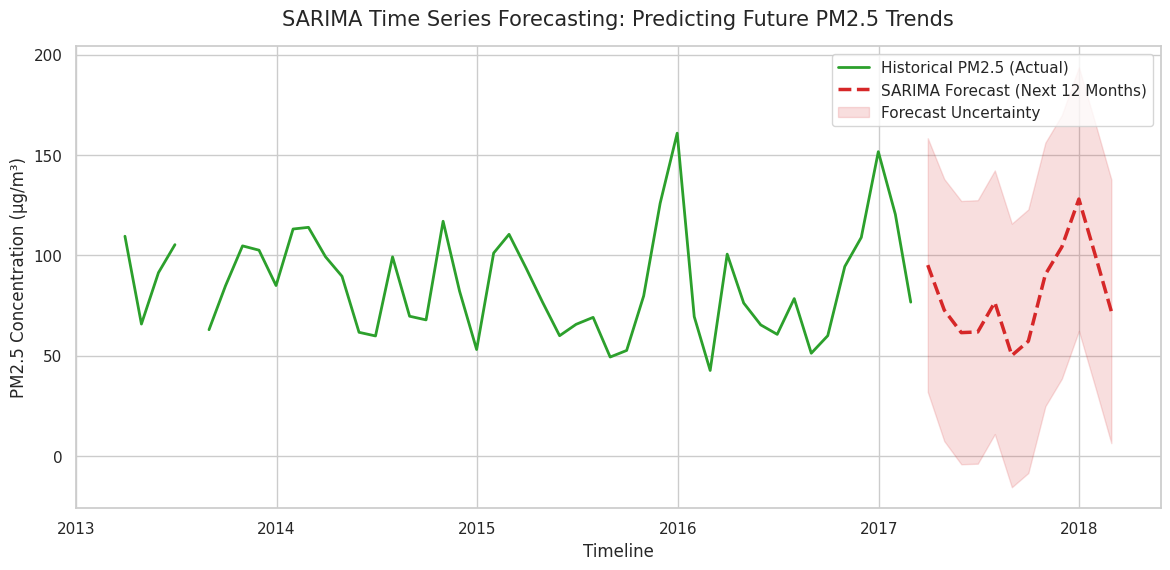

In [16]:
# Import the specific SARIMA tool from statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd


df['datetime'] = pd.to_datetime(df['datetime'])
ts_data = df[df['station'] == 'Dongsi'].copy()
ts_data.set_index('datetime', inplace=True)
ts_monthly = ts_data['PM2.5'].resample('ME').mean()


print("Training the SARIMA Model... (This takes a few seconds)")

# The seasonal_order=(1, 1, 1, 12) tells the model to look for a 12-month repeating cycle
sarima_model = SARIMAX(ts_monthly,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_results = sarima_model.fit(disp=False)

# Forecast the next 12 months into the future
forecast = sarima_results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.figure(figsize=(14, 6))

# Plot the historical data in green
plt.plot(ts_monthly.index, ts_monthly.values, label='Historical PM2.5 (Actual)', color='#2ca02c', linewidth=2)

# Plot the forecasted data in dashed red
plt.plot(forecast_mean.index, forecast_mean.values, label='SARIMA Forecast (Next 12 Months)', color='#d62728', linestyle='--', linewidth=2.5)

# Add the shaded red confidence interval
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='#d62728', alpha=0.15, label='Forecast Uncertainty')

plt.title('SARIMA Time Series Forecasting: Predicting Future PM2.5 Trends', fontsize=15, pad=15)
plt.xlabel('Timeline', fontsize=12)
plt.ylabel('PM2.5 Concentration (µg/m³)', fontsize=12)
plt.legend(loc='upper right')
plt.show()